# Gradient Boosting — Classification

---

## 1. Problem Setup

Assume we have a dataset

$$
\{(x_i, y_i)\}_{i=1}^{N}
$$

where

$$
x_i \in \mathbb{R}^D
$$

and

$$
y_i \in \{0,1\}
$$

The goal is to learn a model

$$
F(x) : \mathbb{R}^D \to [0,1]
$$

that predicts the probability of the positive class.

---

## 2. Model Structure

Gradient Boosting builds an additive model of the form:

$$
F_M(x) = F_0(x) + \alpha \sum_{m=1}^M \gamma_m h_m(x)
$$

where:

- $F_0(x)$ is the initial prediction (log-odds of positive class)
- $h_m(x)$ is the $m$-th base learner (decision tree)
- $\gamma_m$ is the leaf value update
- $\alpha$ is the learning rate
- $M$ is the number of estimators

---

## 3. Loss Function

For classification, the logistic loss is used:

$$
\mathcal{L}(y, F(x)) = - \sum_{i=1}^N \left[y_i \log p_i + (1-y_i) \log (1-p_i)\right]
$$

where

$$
p_i = \sigma(F(x_i)) = \frac{1}{1 + e^{-F(x_i)}}
$$

---

## 4. Initial Prediction

The model starts with

$$
F_0 = \log \frac{\bar{y}}{1-\bar{y}}
$$

where $\bar{y}$ is the mean of $y$.

---

## 5. Residuals (Negative Gradient)

At iteration $m$, compute pseudo-residuals:

$$
r_i^{(m)} = - \left. \frac{\partial \mathcal{L}(y_i, F(x_i))}{\partial F(x_i)} \right|_{F(x_i) = F_{m-1}(x_i)}
= y_i - \sigma(F_{m-1}(x_i))
$$

These residuals become the target for the next tree.

---

## 6. Fit Base Learner

Fit a regression tree $h_m(x)$ to predict $r_i^{(m)}$:

$$
h_m = \arg\min_h \sum_i \left(r_i^{(m)} - h(x_i)\right)^2
$$

---

## 7. Leaf Value Update

For each leaf $\ell$ in the tree, compute:

$$
\gamma_{m,\ell} = \frac{\sum_{i \in \ell} r_i^{(m)}}{\sum_{i \in \ell} p_i (1 - p_i)}
$$

Update the prediction:

$$
F_m(x) = F_{m-1}(x) + \alpha \sum_\ell \gamma_{m,\ell} \mathbf{1}\{x \in \ell\}
$$

---

## 8. Feature Subsampling

Optionally, only a fraction of features is used per tree:

$$
\mathcal{F} \subseteq \{1,2,\dots,D\}, \quad |\mathcal{F}| = \text{feature\_fraction} \cdot D
$$

---

## 9. Prediction Rule

For a new sample $x$:

1. Traverse each tree $h_m(x)$ to determine the leaf $\ell$
2. Sum the leaf contributions:

$$
F_M(x) = F_0 + \alpha \sum_{m=1}^M \gamma_{m,\ell}
$$

3. Apply sigmoid for probability:

$$
\hat{p}(x) = \sigma(F_M(x)) = \frac{1}{1 + e^{-F_M(x)}}
$$

Final class prediction:

$$
\hat{y}(x) = 
\begin{cases}
1 & \hat{p}(x) \ge 0.5 \\
0 & \hat{p}(x) < 0.5
\end{cases}
$$

---

## 10. Algorithm Summary

1. Initialize $F_0$ as log-odds
2. For $m = 1$ to $M$:
    - Compute residuals $r_i^{(m)}$
    - Fit base learner $h_m(x)$ to $r_i^{(m)}$
    - Compute leaf values $\gamma_{m,\ell}$
    - Update $F_m(x) = F_{m-1}(x) + \alpha \sum_\ell \gamma_{m,\ell}$
3. Output $F_M(x)$

---

## 11. Bias–Variance Perspective

- Weak learners → high bias initially:

$$
\text{Bias}^2 \downarrow \text{ as } M \uparrow
$$

- Too many iterations → variance increases:

$$
\text{Variance} \uparrow \text{ as } M \uparrow
$$

Gradient Boosting trades off bias and variance by controlling $M$ and $\alpha$.

---

In [1]:
class LeafNode:
    """
    Represents a leaf node in a decision tree.

    Attributes
    ----------
    indices : np.ndarray
        Array of row indices in the dataset that belong to this leaf node.
    """
    def __init__(self,indices):
        self.indices= indices

In [2]:
class DecisionNode:
    """
    Represents an internal (decision) node in a decision tree.

    Attributes
    ----------
    best_threshold : float
        The threshold value used to split the data at this node.
    best_feature : int
        Index of the feature used for splitting.
    left_child : DecisionNode or LeafNode
        Reference to the left child node (samples <= threshold go here).
    right_child : DecisionNode or LeafNode
        Reference to the right child node (samples > threshold go here).
    """
    def __init__(self,best_threshold , best_feature , left_child , right_child):
        self.best_threshold = best_threshold
        self.best_feature = best_feature
        self.left_child = left_child
        self.right_child = right_child

In [3]:
class DecisionTreeRegressor:
    """
    Decision Tree Regressor supporting MSE, MAE, and Huber loss.

    Parameters
    ----------
    max_depth : int, default=10
        Maximum depth of the tree.

    feature_fraction : float, default=1.0
        Fraction of features randomly selected at each split.

    scoring : str, default='mse'
        Loss function used for splitting.
        Options: 'mse', 'mae', 'huber'

    min_sample_split : int, default=1
        Minimum number of samples required to split.

    delta : float, default=0.5
        Threshold parameter for Huber loss.

    Attributes
    ----------
    root : Node
        Root node of the decision tree.
    """
    def __init__(self, max_depth = 10 , feature_fraction = 1 , scoring='mse', min_sample_split=1 , delta=0.5):
        self.max_depth = max_depth
        self.feature_fraction = feature_fraction
        self.scoring = scoring
        self.min_sample_split = min_sample_split
        self.delta = delta
        self.root = None

        # Validate
        if type(self.max_depth) != int or self.max_depth <= 0:
            raise ValueError('Max depth must be a positive integer')
        if type(self.min_sample_split) != int or self.min_sample_split <= 0:
            raise ValueError('Min samples split must be a positive integer')
        if self.scoring not in ['mse', 'mae','huber']:
            raise ValueError("Scoring must be either 'mse', 'mae' or 'huber'")   
        if not (0 < self.feature_fraction <= 1):
            raise ValueError("feature_fraction must be in the range (0, 1].")
        if self.delta <= 0:
            raise ValueError("delta must be strictly greater than 0.")
            
    def _random_feature_sampling(self, data):
        """
        Randomly select a subset of features.

        Returns
        -------
        selected_features : array-like
            Indices of selected features.
        """
        num_features = data.shape[1]-1 # exclude target column
        total_features_selected = max(1,round(self.feature_fraction * num_features ))
        selected_features = np.random.choice(num_features,total_features_selected,replace=False)

        return selected_features

    def _stopping_condition(self,data,depth , indices):
        """
        Check whether to stop splitting.

        Stops if:
        - Maximum depth reached
        - Not enough samples
        - Target variance is zero
        """
        if depth >= self.max_depth:
            return True
        if len(indices) < self.min_sample_split:
            return True
        if np.var(data[indices,-1])==0:
            return True
        return False

    def _leaf_prediction(self,y):
        """
        Compute prediction for a leaf node.

        Returns mean (MSE/HUBER) or median (MAE).
        """
        if self.scoring == 'mae':
            return np.median(y)
        else :
            return np.mean(y)
    
    def _all_thresholds(self, data, selected_features):
        """
        Generate candidate thresholds for each selected feature.
        """
        all_thresholds = []
        for feature in selected_features:
            unique_values = np.unique(data[:,feature])
            if len(unique_values) ==1:
                all_thresholds.append(np.array([]))
            else :
                # Midpoints between consecutive sorted values
                unique_averages = (unique_values[1:] + unique_values[:-1])/2
                all_thresholds.append(unique_averages)

        return all_thresholds


    def _split(self,data,feature,threshold,indices):
        """
        Split indices based on threshold for a given feature.

        Returns
        -------
        left_indices, right_indices : tuple of arrays
        """
        condition = data[indices,feature] <= threshold
        left_indices = indices[condition]
        right_indices = indices[~condition]

        return left_indices , right_indices


    def _mse_loss(self,y):
        """Mean Squared Error (variance)."""
        return np.var(y)

    def _mae_loss(self,y):
        """Mean Absolute Error."""
        return np.mean(np.abs(y-np.median(y)))

    def _huber_loss(self,y):
        """Huber loss (robust to outliers)."""
        r = y- np.mean(y)
        r_abs = np.abs(r)

        return np.mean(np.where(r_abs <= self.delta ,(0.5*r*r), self.delta * r_abs - 0.5* (self.delta**2)))

    def _score(self, y_left , y_right):
        """
        Compute weighted loss for a split.
        """
        n_left = len(y_left)
        n_right = len(y_right)

        if n_left == 0 or n_right==0:
            return np.inf

        total = n_left + n_right
        if self.scoring =='mse':
            left_score = self._mse_loss(y_left) 
            right_score = self._mse_loss(y_right) 

        elif self.scoring =='mae':
            left_score = self._mae_loss(y_left)
            right_score = self._mae_loss(y_right)

        elif self.scoring =='huber':
            left_score = self._huber_loss(y_left)
            right_score = self._huber_loss(y_right)  

        return (n_left*left_score + n_right*right_score) / total

    def _best_feature_threshold(self,data,selected_features,all_thresholds,indices):
        best_feature = None
        best_threshold = None
        best_score = np.inf

        for i , feature in enumerate(selected_features):
            threshold = all_thresholds[i]
            for t in threshold:
                left_indices , right_indices = self._split(data,feature,t,indices)
                left_y = data[left_indices,-1]
                right_y = data[right_indices,-1]
                score = self._score(left_y,right_y)
                if score < best_score:
                    best_feature = feature
                    best_threshold = t
                    best_score = score


        return best_feature , best_threshold

    def _find_best_split(self,data,indices):
        """
        Select features and compute best split.
        """
        selected_features = self._random_feature_sampling(data)

        all_thresholds = self._all_thresholds(data, selected_features)

        best_feature , best_threshold = self._best_feature_threshold(data,selected_features,all_thresholds,indices)

        return best_feature , best_threshold


    def _build_tree(self,data,depth,indices):
        """
        Recursively build the decision tree.
        """
        if self._stopping_condition(data,depth,indices):
            return LeafNode(indices)

        best_feature , best_threshold = self._find_best_split(data,indices)

        if best_feature is None:
            return LeafNode(indices)
        

        left_indices , right_indices = self._split(data, best_feature, best_threshold,indices)

        if len(left_indices) == 0 or len(right_indices) == 0:
            return LeafNode(indices)

        left_child = self._build_tree(data,depth+1,left_indices)
        right_child = self._build_tree(data,depth+1,right_indices)


        return DecisionNode(best_threshold , best_feature , left_child , right_child)

    def fit(self,X,y):
        """
        Train the decision tree.

        Parameters
        ----------
        X : array-like of shape (N, D)
            Feature matrix

        y : array-like of shape (N,)
            Target values
        """
        X = np.asarray(X)
        y = np.asarray(y)

        y = y.reshape(-1)


        if X.ndim==1:
            X = X.reshape(-1,1)
        data = np.column_stack((X,y))
        indices = np.arange(len(data))
        self.root = self._build_tree(data , 0, indices)

In [4]:
class GradientBoostingClassifier:
    """
    Gradient Boosting Classifier using decision trees as weak learners.

    Parameters
    ----------
    n_estimators : int, default=100
        Number of boosting rounds (trees) to fit.

    alpha : float, default=0.01
        Learning rate that scales the contribution of each tree.

    max_depth : int, default=1
        Maximum depth of each regression tree.

    min_sample_split : int, default=1
        Minimum number of samples required to split a node in the base tree.

    scoring : str, default='mse'
        Loss function used in base regression trees. Options: 'mse', 'mae', 'huber'.

    feature_fraction : float, default=1
        Fraction of features randomly selected for each tree (feature subsampling).

    Attributes
    ----------
    models : list
        Stores all fitted decision tree models.

    leaf_values : list
        Stores gamma (leaf output) values for each tree.

    f0_pred : float
        Initial prediction (log-odds) based on mean of targets.
    """
    def __init__(self,n_estimators=100, alpha=0.01, max_depth =1 , min_sample_split=1 , scoring='mse', feature_fraction=1 ):
        self.n_estimators = n_estimators
        self.alpha = alpha
        self.max_depth = max_depth
        self.min_sample_split = min_sample_split
        self.scoring = scoring
        self.feature_fraction = feature_fraction

        self.models = []       # store all trees
        self.leaf_values = []  # store gamma values per tree

    def _loss_function(self,y,p):
        """
        Compute binary cross-entropy loss.

        Parameters
        ----------
        y : array-like
            True binary labels.

        p : array-like
            Predicted probabilities.

        Returns
        -------
        float
            Total loss over all samples.
        """
        eps = 1e-10
        loss = -np.sum(y * np.log(p + eps) + (1-y) * np.log(1-p + eps))
        return loss

    def _sigmoid(self,fx):
        """
        Numerically stable sigmoid function.

        Parameters
        ----------
        fx : array-like
            Input scores (logits).

        Returns
        -------
        array-like
            Sigmoid probabilities.
        """
        output = np.zeros_like(fx)
        pos_indices = fx>0
        neg_indices = ~pos_indices
        # For negative logits
        exp_x = np.exp(fx[neg_indices])
        output[neg_indices] = exp_x/(1+exp_x)
        # For positive logits
        exp_neg_x = np.exp(-fx[pos_indices])
        output[pos_indices] = 1 / (1 + exp_neg_x)

        return output

    def _get_leaf_indices(self, tree, X):
        """
        Determine which leaf each sample belongs to in a tree.

        Parameters
        ----------
        tree : DecisionNode or LeafNode
            Root node of the tree.

        X : array-like, shape (N, D)
            Input feature matrix.

        Returns
        -------
        leaf_idx : array-like, shape (N,)
            Leaf index for each sample.
        """
        n_samples = X.shape[0]
        leaf_idx = np.zeros(n_samples, dtype=int)
        
        def recurse(node, idx_array, leaf_counter):
            # If node is leaf, assign current leaf number
            if isinstance(node, LeafNode):
                leaf_idx[idx_array] = leaf_counter[0]
                leaf_counter[0] += 1
            else:
                feature = node.best_feature
                threshold = node.best_threshold
                left_mask = X[idx_array, feature] <= threshold
                right_mask = ~left_mask
                if np.any(left_mask):
                    recurse(node.left_child, idx_array[left_mask], leaf_counter)
                if np.any(right_mask):
                    recurse(node.right_child, idx_array[right_mask], leaf_counter)
        
        recurse(tree, np.arange(n_samples), [0])
        return leaf_idx

    def _compute_gamma(self, y, p, leaf_idx):
        """
        Compute leaf output (gamma) for gradient boosting.

        Parameters
        ----------
        y : array-like, shape (N, 1)
            True labels.

        p : array-like, shape (N, 1)
            Predicted probabilities.

        leaf_idx : array-like, shape (N,)
            Leaf indices for each sample.

        Returns
        -------
        gamma : array-like
            Output values per leaf.
        """
        unique_leaves = np.unique(leaf_idx)
        gamma = np.zeros(len(unique_leaves))
        for leaf in unique_leaves:
            indices = np.where(leaf_idx == leaf)[0]
            numerator = np.sum(y[indices] - p[indices])
            denominator = np.sum(p[indices] * (1 - p[indices])) + 1e-10
            gamma[leaf] = numerator / denominator
        return gamma
    
    def fit(self,X,y):
        """
        Compute leaf output (gamma) for gradient boosting.

        Parameters
        ----------
        y : array-like, shape (N, 1)
            True labels.

        p : array-like, shape (N, 1)
            Predicted probabilities.

        leaf_idx : array-like, shape (N,)
            Leaf indices for each sample.

        Returns
        -------
        gamma : array-like
            Output values per leaf.
        """
        X = np.asarray(X)
        y = np.asarray(y).reshape(-1, 1)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        # Initialize prediction with log-odds
        p = np.mean(y)
        self.f0_pred = np.log( p/(1-p + 1e-10) )
        Fm = np.full_like(y, self.f0_pred  , dtype=float)

        for i in range(self.n_estimators):
            # Initialize prediction with log-odds
            model = DecisionTreeRegressor(max_depth = self.max_depth , 
                                           min_sample_split=self.min_sample_split , scoring=self.scoring, 
                                           feature_fraction=self.feature_fraction )

            p_m_1 = self._sigmoid(Fm)
            residual = y - p_m_1
            model.fit(X,residual)
        
            leaf_idx = self._get_leaf_indices(model.root, X)
            gamma = self._compute_gamma(y, p_m_1, leaf_idx)

            # Update predictions
            for leaf in np.unique(leaf_idx):
                Fm[leaf_idx == leaf] += self.alpha * gamma[leaf]

            # Store tree and leaf gamma
            self.models.append(model)
            self.leaf_values.append(gamma)

    def predict_proba(self, X):
        """
        Compute class probabilities for input samples.

        Parameters
        ----------
        X : array-like, shape (N, D)
            Feature matrix.

        Returns
        -------
        array-like, shape (N, 2)
            Probability for [class0, class1].
        """
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        Fm = np.full((X.shape[0], 1), self.f0_pred, dtype=float)

        for model, gamma in zip(self.models, self.leaf_values):
            leaf_idx = self._get_leaf_indices(model.root, X)
            for leaf in np.unique(leaf_idx):
                Fm[leaf_idx == leaf] += self.alpha * gamma[leaf]

        p = self._sigmoid(Fm)
        return np.hstack((1 - p, p))  # probability for [class0, class1]

    def predict(self, X):
        """
        Predict binary class labels for input samples.

        Parameters
        ----------
        X : array-like, shape (N, D)
            Feature matrix.

        Returns
        -------
        array-like, shape (N,)
            Predicted class labels (0 or 1).
        """
        proba = self.predict_proba(X)
        return (proba[:, 1] >= 0.5).astype(int)

# Gradient Boosting — Learning Curves (Log-Loss vs Number of Trees)

---

## 1. Objective

The goal of is to analyze how the performance of a Gradient Boosting Classifier evolves as the number of boosting iterations increases.

Track:

- Training Log-Loss  
- Test Log-Loss  

as a function of the number of trees:

$$
M = 1, 2, \dots, n_{\text{estimators}}
$$

---



## 2. Model Initialization

Gradient Boosting builds an additive model:

$$
F_0 = \log \left( \frac{p}{1-p} \right)
$$

where:

$$
p = \mathbb{E}[y]
$$

At iteration $m$:

$$
F_m(x) = F_{m-1}(x) + \alpha \cdot \gamma_m \cdot h_m(x)
$$

---


## 3. Steps

For each boosting iteration:

1. Update predictions:

$$
F_m = F_{m-1} + \alpha \cdot \gamma_m \cdot h_m(x)
$$

2. Compute probabilities:

$$
p_m = \sigma(F_m)
$$

3. Compute training and test loss.

---

## 4. Track train and test loss

We store:

$$
\text{Train Loss}_m
$$

$$
\text{Test Loss}_m
$$

for each:

$$
m = 1, 2, \dots, n_{\text{estimators}}
$$

---

## 5. Observations

Typical expected behavior:

- Initially:

$$
\text{Train Loss} \downarrow, \quad \text{Test Loss} \downarrow
$$

- As trees increase:

$$
\text{Train Loss} \rightarrow 0
$$

- Test loss may:

$$
\downarrow \text{ then } \uparrow
$$

indicating overfitting.

---






 

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate Data
np.random.seed(42)
N = 500   # total samples
D = 5   # features

# Random features
X = np.random.randn(N, D)

# True coefficients
coef = np.random.randn(D, 1)

# Linear combination + noise
logits = X @ coef + 0.5 * np.random.randn(N, 1)

# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

p = sigmoid(logits)
y = (p > 0.5).astype(int).reshape(-1)

# Split into train/test
split = int(0.7 * N)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

clf = GradientBoostingClassifier(n_estimators=1000, alpha=0.1, max_depth=2)
clf.fit(X_train, y_train)

# 5. Compute losses

train_loss = []
test_loss = []

Fm_train = np.full((X_train.shape[0], 1), clf.f0_pred, dtype=float)
Fm_test = np.full((X_test.shape[0], 1), clf.f0_pred, dtype=float)

for model, gamma in zip(clf.models, clf.leaf_values):
    # Get leaf indices for train and test
    leaf_idx_train = clf._get_leaf_indices(model.root, X_train)
    leaf_idx_test = clf._get_leaf_indices(model.root, X_test)
    
    # Update predictions with correct gamma for each sample's leaf
    for leaf in np.unique(leaf_idx_train):
        Fm_train[leaf_idx_train == leaf] += clf.alpha * gamma[leaf]
    
    for leaf in np.unique(leaf_idx_test):
        Fm_test[leaf_idx_test == leaf] += clf.alpha * gamma[leaf]
    
    # Probabilities
    eps = 1e-10
    p_train = clf._sigmoid(Fm_train)
    p_test = clf._sigmoid(Fm_test)
    
    # Log loss
    train_loss.append(-np.mean(y_train.reshape(-1, 1) * np.log(p_train + eps) + 
                                (1 - y_train.reshape(-1, 1)) * np.log(1 - p_train + eps)))
    test_loss.append(-np.mean(y_test.reshape(-1, 1) * np.log(p_test + eps) + 
                              (1 - y_test.reshape(-1, 1)) * np.log(1 - p_test + eps)))

In [6]:
# Results
df_loss = pd.DataFrame({
    "Tree": np.arange(1, clf.n_estimators + 1),
    "Train_LogLoss": train_loss,
    "Test_LogLoss": test_loss
})

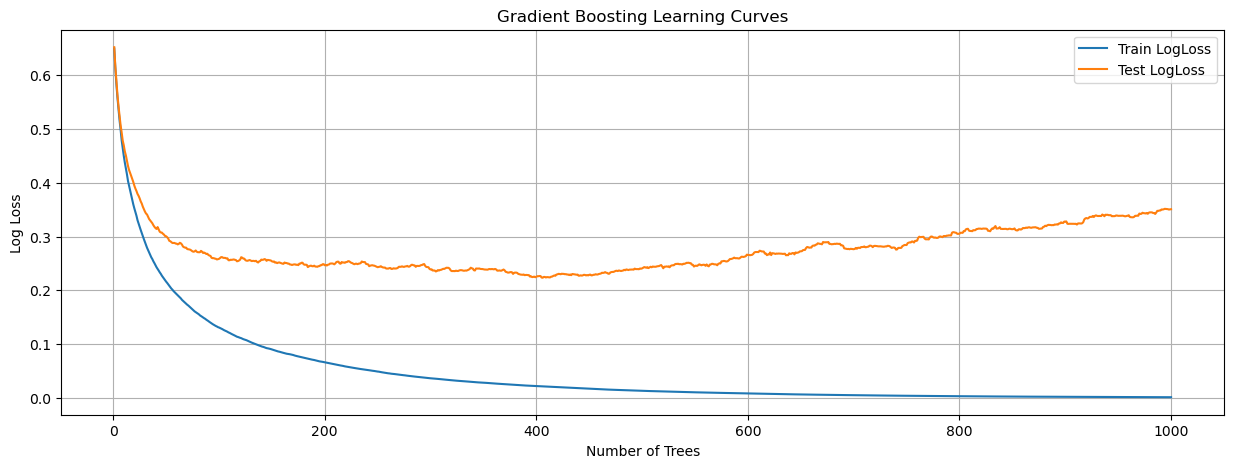

In [7]:
# Plot
plt.figure(figsize=(15, 5))
plt.plot(df_loss["Tree"], df_loss["Train_LogLoss"], label='Train LogLoss')
plt.plot(df_loss["Tree"], df_loss["Test_LogLoss"],  label='Test LogLoss')
plt.xlabel('Number of Trees')
plt.ylabel('Log Loss')
plt.title('Gradient Boosting Learning Curves')
plt.legend()
plt.grid(True)
plt.show()

## 6. Conclusion

This experiment shows how Gradient Boosting evolves as the number of trees increases and how learning curves help diagnose model behavior.

Learning curves are helpful to identify:

- Underfitting  
- Optimal number of trees  
- Overfitting  

As the number of estimators $M$ increases:

- Initially:

$$
\text{Train Loss} \downarrow \quad \text{and} \quad \text{Test Loss} \downarrow
$$

- After a certain point:

$$
\text{Train Loss} \downarrow \quad \text{but} \quad \text{Test Loss} \uparrow
$$

This indicates overfitting.

In this experiment, the optimal number of trees is observed at:

$$
M^* \approx 400
$$

To demonstrate overfitting behavior, the number of estimators was intentionally increased to:

$$
M = 1000
$$

Beyond the optimal point:

$$
M > M^* \Rightarrow   \text{Generalization degrades}
$$

Thus, learning curves allow us to:

- Select the optimal $M$  
- Balance bias and variance  
- Visually detect overfitting  